# 실험② — 코드 · OCR · VLM 역할 분담

**이 노트북이 답할 질문**

> 문서 이미지에서 값을 뽑을 때, **무엇을 누구에게 맡겨야** VLM 의 날조를 막으면서 가장 많이 자동처리하는가?

설계: `docs/code_design.md` 의 `2026-10-03 — 2차 설계` · 근거: `docs/research.md` 의 `2026-10-03` 절

---

# 1. 합성기 — 정답을 먼저 정하고 문서를 그린다

직접 그리므로 **모든 필드의 값과 위치를 처음부터 안다.** 이 정답은 맨 뒤 **채점 절에서만** 쓴다.

In [1]:
from dataclasses import dataclass
from typing import Literal

@dataclass(frozen=True)
class FieldTruth:
    """정답 한 칸. frozen — 실험 도중 정답이 바뀌면 안 된다"""
    name: str                          # "total"
    value: str                         # 찍은 문자열 그대로 "1,234,000" — 숫자 변환은 채점에서
    kind: Literal["num", "text"]       # num → 산수·형식·OCR 대조 / text → OCR 대조만
    bbox: tuple[int, int, int, int]    # x1, y1, x2, y2 (픽셀) — 가리기 · 위치 채점용

In [2]:
from pathlib import Path
import urllib.request
from PIL import ImageFont

# 나눔고딕 — OFL(무료·재배포 가능). 시스템 폰트(AppleSDGothicNeo)는 애플 라이선스라 공개 이미지에 애매하다
FONT_DIR = Path("data/fonts"); FONT_DIR.mkdir(parents=True, exist_ok=True)   # data/ 는 git 제외
FONT_URL = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
FONT_PATH = FONT_DIR / "NanumGothic-Regular.ttf"
if not FONT_PATH.exists():
    urllib.request.urlretrieve(FONT_URL, FONT_PATH)

def font(size: int) -> ImageFont.FreeTypeFont:
    """크기별 폰트. 각주처럼 작은 글씨는 VLM 이 놓치기 쉬운 자리라 일부러 만든다"""
    return ImageFont.truetype(str(FONT_PATH), size)

In [3]:
import random

# 사업자등록번호 — 끝자리가 앞 9자리의 체크섬이다. 그럴듯하게 바꿔 쓴 번호를 정답 없이 잡을 수 있다
BRN_W = [1, 3, 7, 1, 3, 7, 1, 3, 5]   # 국세청 가중치

def brn_check_digit(d9: list[int]) -> int:
    s = sum(d * w for d, w in zip(d9, BRN_W)) + (d9[8] * 5) // 10
    return (10 - s % 10) % 10

def fake_brn(rng: random.Random) -> str:
    """앞 3자리(세무서 코드)를 000 으로 — 실존 코드는 101 부터라 실제 사업자와 겹치지 않는다"""
    d9 = [0, 0, 0] + [rng.randint(0, 9) for _ in range(6)]
    d = d9 + [brn_check_digit(d9)]
    s = "".join(map(str, d))
    return f"{s[:3]}-{s[3:5]}-{s[5:]}"

In [4]:
from datetime import date, timedelta

# 누가 봐도 지어낸 이름만 쓴다 — 공개 저장소라 실존 회사·인물과 겹치면 안 된다
# (주) 앞·뒤 / 주식회사 앞·뒤를 섞는다 — VLM 이 표기를 바꿔 쓰는지 보는 재료
COMPANIES = ["테스트확인 주식회사", "(주)샘플상사", "가상솔루션(주)", "예시테크 주식회사", "(주)모의물산"]
ITEMS = [  # (품목명, 단위, 단가 최소, 최대, 수량 최대) — 값이 현실적이어야 "그럴듯한 오답" 실험이 의미 있다
    ("A4 복사용지 80g", "박스", 18000, 32000, 30),
    ("레이저 토너 카트리지", "개", 45000, 120000, 20),
    ("사무용 의자", "개", 89000, 350000, 15),
    ("유지보수 용역", "식", 500000, 3000000, 1),     # 용역은 1식
    ("네트워크 스위치 24포트", "대", 150000, 900000, 5),
    ("소프트웨어 라이선스(1년)", "카피", 120000, 800000, 10),
]
MANAGERS = ["홍길동", "김아무개", "이아무개", "박아무개", "최아무개"]

def quote_values(rng: random.Random) -> dict:
    """견적서 값만 만든다 (그리기는 다음 단계). 산수는 정답에서 반드시 성립한다"""
    items = []
    for name, unit_name, lo, hi, qmax in rng.sample(ITEMS, rng.randint(2, 5)):
        unit = rng.randrange(lo, hi, 100)          # 실제 단가처럼 100원 단위
        qty = rng.randint(1, qmax)                # 어색한 수량은 VLM 이 "고쳐 쓸" 수 있다
        items.append({"name": name, "unit_name": unit_name, "unit": unit, "qty": qty, "amount": unit * qty})
    supply = sum(i["amount"] for i in items)
    vat = supply // 10                              # 원 미만 버림 — 실물은 반올림도 있어 검산은 ±1원 허용
    supplier, client = rng.sample(COMPANIES, 2)
    return {
        "doc_no": f"Q-2026-{rng.randint(1, 999):04d}",
        "date": (date(2026, 1, 1) + timedelta(days=rng.randint(0, 270))).isoformat(),
        "supplier": supplier, "supplier_brn": fake_brn(rng),
        "client": client, "client_brn": fake_brn(rng),
        "manager": rng.choice(MANAGERS),
        "items": items, "supply": supply, "vat": vat, "total": supply + vat,
    }

quote_values(random.Random(0))

{'doc_no': 'Q-2026-0634',
 'date': '2026-05-09',
 'supplier': '(주)샘플상사',
 'supplier_brn': '000-89-24119',
 'client': '테스트확인 주식회사',
 'client_brn': '000-57-81569',
 'manager': '이아무개',
 'items': [{'name': '유지보수 용역',
   'unit_name': '식',
   'unit': 1826800,
   'qty': 1,
   'amount': 1826800},
  {'name': 'A4 복사용지 80g',
   'unit_name': '박스',
   'unit': 30200,
   'qty': 12,
   'amount': 362400},
  {'name': '사무용 의자',
   'unit_name': '개',
   'unit': 327900,
   'qty': 15,
   'amount': 4918500},
  {'name': '소프트웨어 라이선스(1년)',
   'unit_name': '카피',
   'unit': 298900,
   'qty': 9,
   'amount': 2690100},
  {'name': '레이저 토너 카트리지',
   'unit_name': '개',
   'unit': 59200,
   'qty': 10,
   'amount': 592000}],
 'supply': 10389800,
 'vat': 1038980,
 'total': 11428780}

In [5]:
from PIL import Image, ImageDraw

def put(draw: ImageDraw.ImageDraw, truths: list, xy, text: str, size: int,
        name: str | None = None, kind: str = "text", anchor: str = "la"):
    """글자를 그리고, name 이 있으면 그린 위치 그대로 정답에 기록한다.
       라벨("합계")은 name 없이 그리기만 — 채점 대상은 값이다. 금액 열은 anchor="ra"(오른쪽 정렬)"""
    f = font(size)
    draw.text(xy, text, font=f, fill="black", anchor=anchor)
    if name:
        truths.append(FieldTruth(name, text, kind, tuple(draw.textbbox(xy, text, font=f, anchor=anchor))))

# 확인 — 라벨은 기록되지 않고 값만 남는다
_img = Image.new("RGB", (400, 60), "white"); _d = ImageDraw.Draw(_img); _t = []
put(_d, _t, (10, 20), "합계", 20)
put(_d, _t, (390, 20), "71,901,390", 20, name="total", kind="num", anchor="ra")
_t

[FieldTruth(name='total', value='71,901,390', kind='num', bbox=(282, 23, 390, 41))]

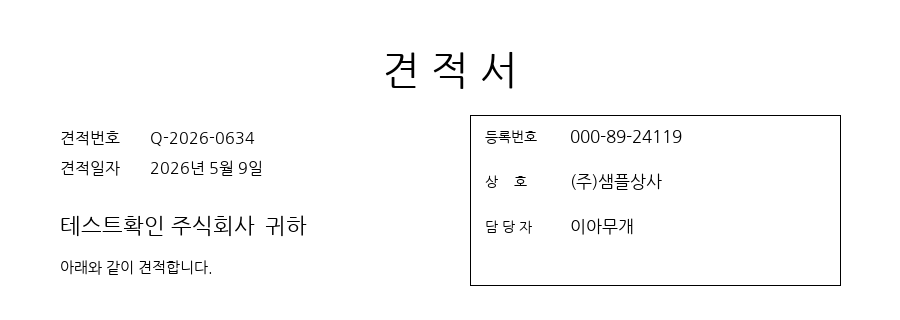

In [6]:
W, H = 900, 1273   # A4 비율. 이 크기의 이미지 토큰은 미측정 — 1일차 첫 호출에서 잰다

def draw_quote_header(d, t, v):
    """상단 — 제목 · 번호 · 날짜 · 공급받는자 · 공급자 박스"""
    put(d, t, (W // 2, 50), "견 적 서", 40, anchor="ma")
    y, m, dd = map(int, v["date"].split("-"))
    put(d, t, (60, 130), "견적번호", 16);  put(d, t, (150, 130), v["doc_no"], 16, name="doc_no", kind="num")
    # 날짜는 한국식으로 찍는다 — VLM 이 ISO 로 바꿔 쓰는지가 V1("보이는 그대로") 관찰 포인트
    put(d, t, (60, 160), "견적일자", 16);  put(d, t, (150, 160), f"{y}년 {m}월 {dd}일", 16, name="date", kind="num")
    put(d, t, (60, 215), v["client"], 22, name="client")
    put(d, t, (60 + d.textlength(v["client"], font=font(22)) + 10, 215), "귀하", 22)
    put(d, t, (60, 260), "아래와 같이 견적합니다.", 15)
    # 공급자 박스 — 라벨·값이 붙어 있어 공급자/공급받는자를 바꿔 읽는 실패가 생길 수 있는 자리
    d.rectangle((470, 115, 840, 285), outline="black")
    put(d, t, (485, 130), "등록번호", 14);  put(d, t, (570, 128), v["supplier_brn"], 17, name="supplier_brn", kind="num")
    put(d, t, (485, 175), "상    호", 14);  put(d, t, (570, 173), v["supplier"], 17, name="supplier")
    put(d, t, (485, 220), "담 당 자", 14);  put(d, t, (570, 218), v["manager"], 17, name="manager")

# 미리보기 — 상단만
_v = quote_values(random.Random(0))
_img = Image.new("RGB", (W, H), "white"); _t = []
draw_quote_header(ImageDraw.Draw(_img), _t, _v)
_img.crop((0, 0, W, 320))

26 개 필드 기록


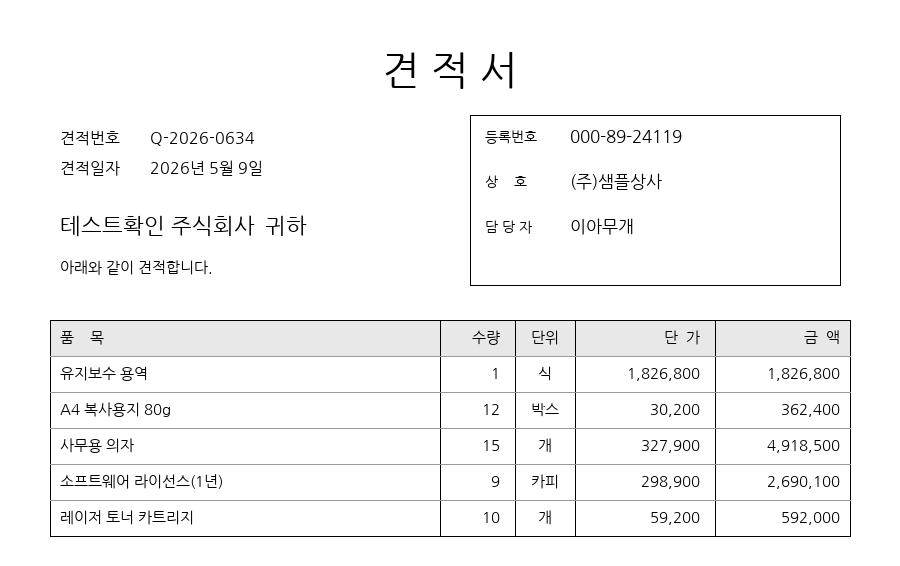

In [7]:
ROW_H = 36
COLS = [("품    목", 60, "la"), ("수량", 500, "ra"), ("단위", 545, "ma"), ("단  가", 700, "ra"), ("금  액", 840, "ra")]
V_LINES = [440, 515, 575, 715]   # 세로 칸막이

def draw_quote_items(d, t, v, top=320) -> int:
    """품목 표. 촘촘한 줄 = 이름-금액을 옆 줄과 짝지어 읽는 실패가 나는 자리 (CORD names 61%).
       표 아래 y 를 돌려준다 — 품목 수가 문서마다 달라서"""
    bottom = top + ROW_H * (len(v["items"]) + 1)
    d.rectangle((50, top, 850, top + ROW_H), fill="#e8e8e8")
    d.rectangle((50, top, 850, bottom), outline="black")
    for x in V_LINES:
        d.line((x, top, x, bottom), fill="black")
    for label, x, anc in COLS:
        put(d, t, (x, top + 10), label, 15, anchor=anc)
    for i, it in enumerate(v["items"]):
        y = top + ROW_H * (i + 1)
        d.line((50, y, 850, y), fill="#999999")
        put(d, t, (60, y + 10), it["name"], 15, name=f"item{i}.name")
        put(d, t, (500, y + 10), str(it["qty"]), 15, name=f"item{i}.qty", kind="num", anchor="ra")
        put(d, t, (545, y + 10), it["unit_name"], 15, anchor="ma")
        put(d, t, (700, y + 10), f"{it['unit']:,}", 15, name=f"item{i}.unit", kind="num", anchor="ra")
        put(d, t, (840, y + 10), f"{it['amount']:,}", 15, name=f"item{i}.amount", kind="num", anchor="ra")
    return bottom

# 미리보기 — 상단 + 표
_img = Image.new("RGB", (W, H), "white"); _d = ImageDraw.Draw(_img); _t = []
draw_quote_header(_d, _t, _v)
_b = draw_quote_items(_d, _t, _v)
print(len(_t), "개 필드 기록")
_img.crop((0, 0, W, _b + 30))

In [8]:
DIGITS = "영일이삼사오육칠팔구"
SMALL = ["", "십", "백", "천"]
BIG = ["", "만", "억", "조"]

def won_korean(n: int) -> str:
    """11428780 → 일천일백사십이만팔천칠백팔십. 네 자리씩 끊어 만·억·조를 붙인다.
       '일'을 생략하지 않는다(일십·일천) — 위조 방지용 공문서·금융 관행"""
    out = []
    for gi in range(len(BIG)):
        g = (n // 10 ** (4 * gi)) % 10000
        if not g:
            continue
        s = "".join(DIGITS[(g // 10 ** si) % 10] + SMALL[si]
                    for si in range(3, -1, -1) if (g // 10 ** si) % 10)
        out.append(s + BIG[gi])
    return "".join(reversed(out)) or "영"

[(n, won_korean(n)) for n in (11428780, 10, 10005, 100000000, 0)]

[(11428780, '일천일백사십이만팔천칠백팔십'),
 (10, '일십'),
 (10005, '일만오'),
 (100000000, '일억'),
 (0, '영')]

30 개 필드 기록 · ['vat', 'total', 'total_kor']


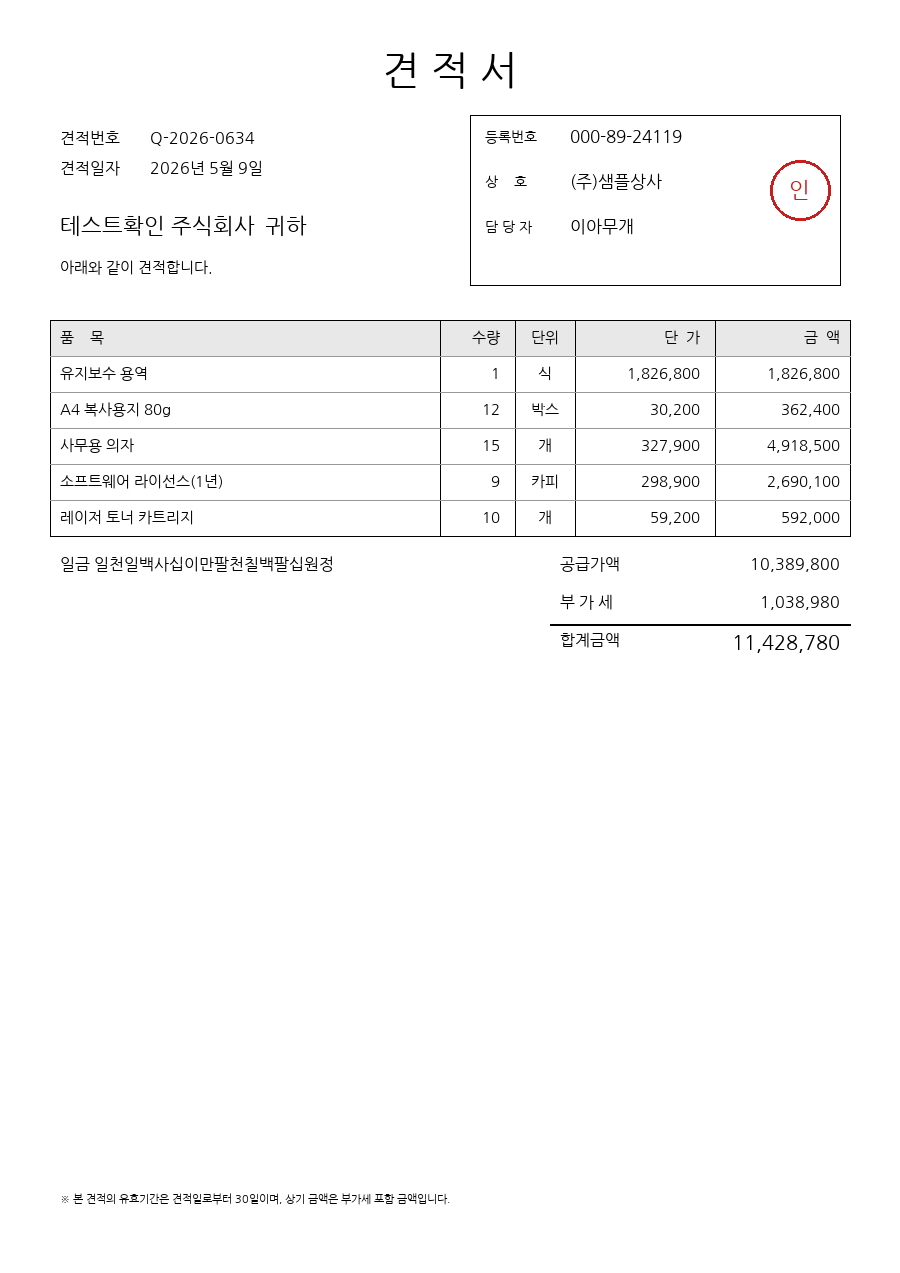

In [9]:
STAMP = (200, 30, 30)

def draw_quote_footer(d, t, v, top):
    """합계 세 줄(검산 재료) · 직인(방해 요소, 기록 안 함) · 작은 각주"""
    rows = [("공급가액", "supply", 16), ("부 가 세", "vat", 16), ("합계금액", "total", 20)]
    for i, (label, key, size) in enumerate(rows):
        y = top + 20 + i * 38
        put(d, t, (560, y), label, 16)
        put(d, t, (840, y), f"{v[key]:,}", size, name=key, kind="num", anchor="ra")
    d.line((550, top + 88, 850, top + 88), fill="black", width=2)
    # 한글 금액 — 같은 값을 다른 문자로 한 번 더. 검산 장치가 숫자 합계와 대조한다
    put(d, t, (60, top + 20), f"일금 {won_korean(v['total'])}원정", 16, name="total_kor")
    # 직인 — 지금은 글자에 겹치지 않게. 글자를 덮는 직인은 열화 단계에서 다룬다
    d.ellipse((770, 160, 830, 220), outline=STAMP, width=3)
    d.text((800, 190), "인", font=font(22), fill=STAMP, anchor="mm")
    put(d, t, (60, H - 80), "※ 본 견적의 유효기간은 견적일로부터 30일이며, 상기 금액은 부가세 포함 금액입니다.", 11)

def draw_quote(v: dict) -> tuple[Image.Image, list[FieldTruth]]:
    """견적서 한 장 — 이미지와 정답 목록"""
    img = Image.new("RGB", (W, H), "white"); d = ImageDraw.Draw(img); t = []
    draw_quote_header(d, t, v)
    bottom = draw_quote_items(d, t, v)
    draw_quote_footer(d, t, v, bottom)
    return img, t

_img, _t = draw_quote(_v)
print(len(_t), "개 필드 기록 ·", [f.name for f in _t[-3:]])
_img